**HOUSE PRICE PREDICTION**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/boston.csv")
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


**CRIM** – Per capita crime rate by town.

**ZN** – Proportion of residential land zoned for lots over 25,000 sq. ft.

**INDUS** – Proportion of non-retail business acres per town.

**CHAS** – Charles River dummy variable (1 if the tract bounds the river, 0 otherwise).

**NOX** – Nitric oxides concentration (parts per 10 million).

**RM** – Average number of rooms per dwelling.

**AGE** – Proportion of owner-occupied units built before 1940.

**DIS** – Weighted distances to five Boston employment centers.

**RAD** – Index of accessibility to radial highways.

**TAX** – Full-value property tax rate per $10,000.

**PTRATIO** – Pupil–teacher ratio by town.

**B** – A variable calculated as 1000(Bk−0.63) 2 , where Bk is the proportion of Black residents by town.

**LSTAT** – Percentage of lower-status population.

**MEDV** – Median value of owner-occupied homes (in $1000s).

In [ ]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [ ]:
df.duplicated().sum()

np.int64(0)

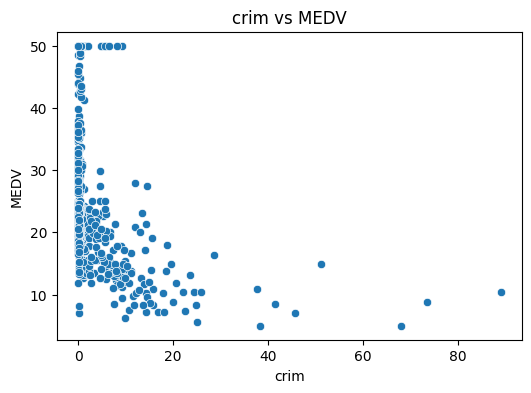

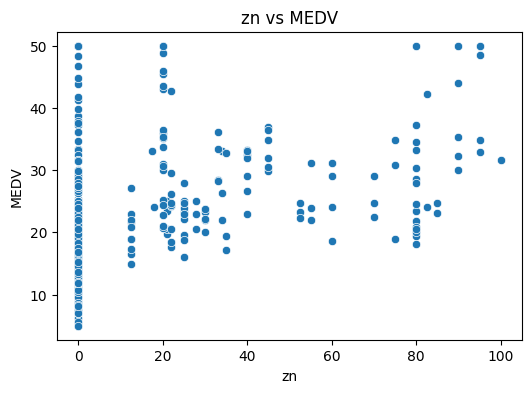

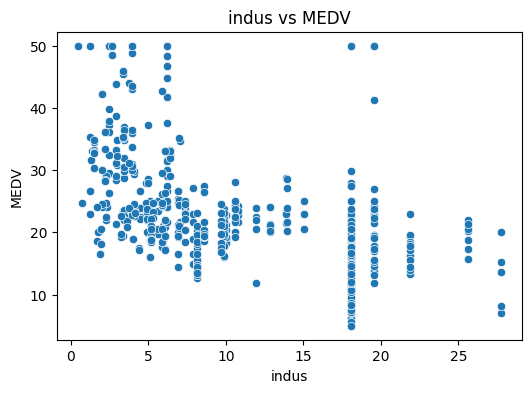

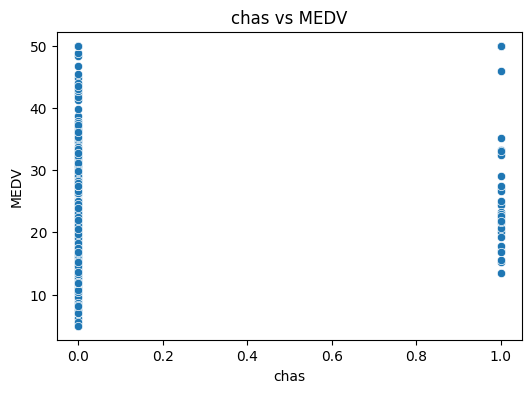

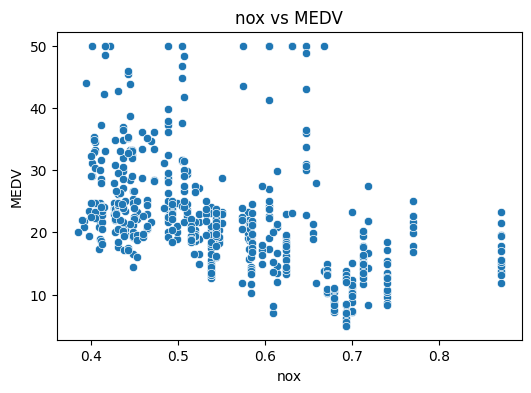

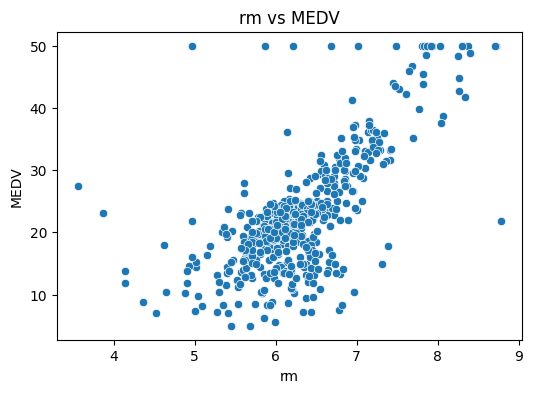

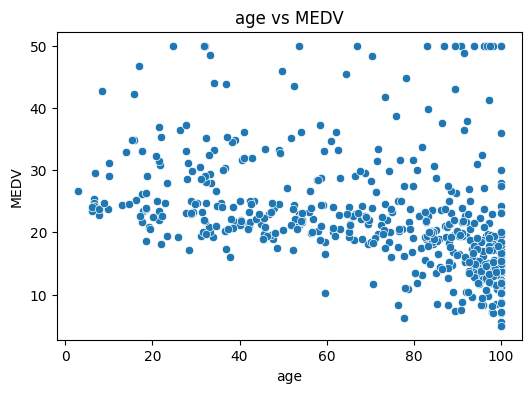

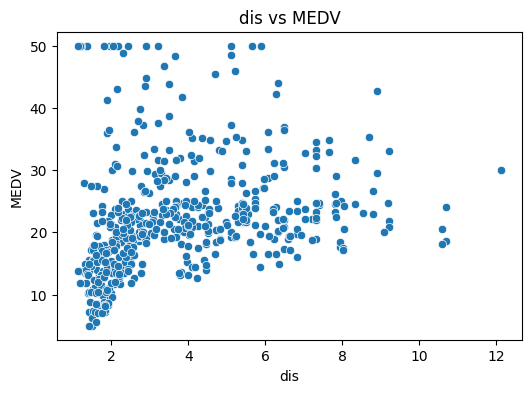

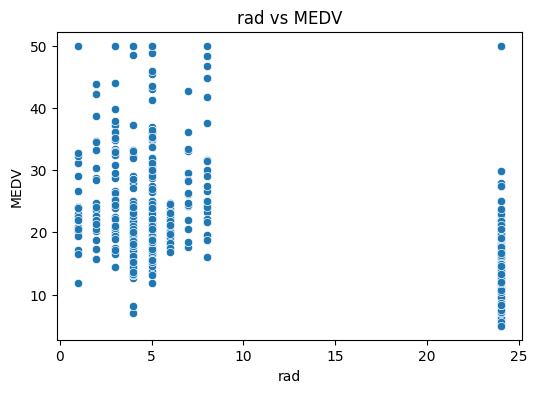

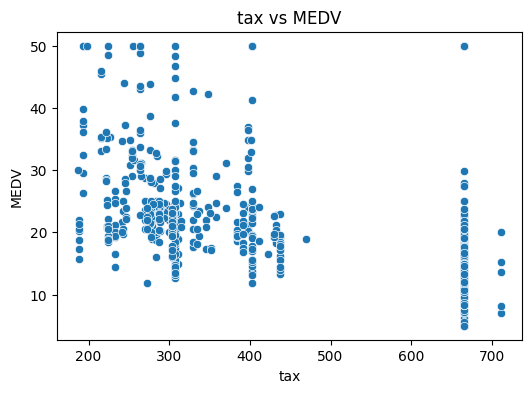

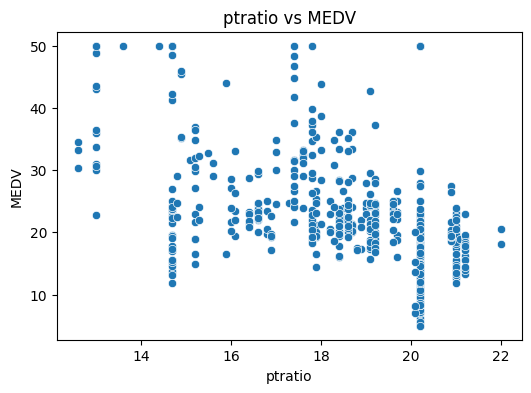

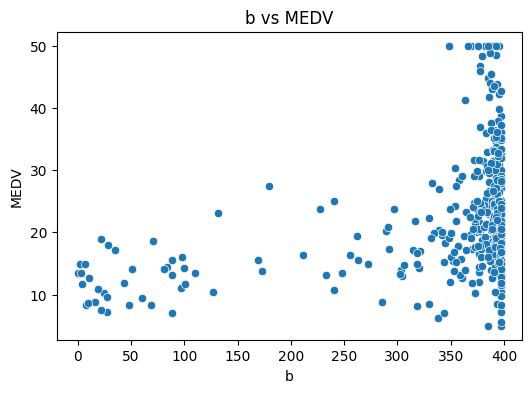

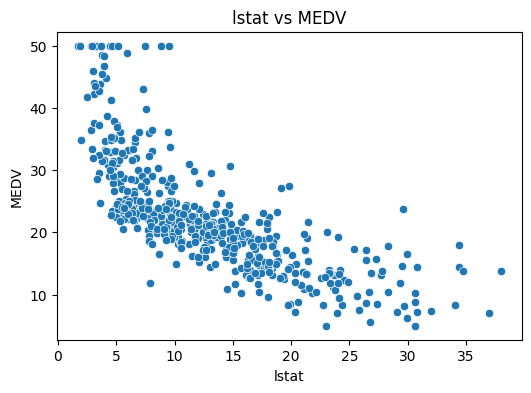

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
features = df.columns.drop("medv")

for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feature], y=df["medv"])
    plt.title(f"{feature} vs MEDV")
    plt.xlabel(feature)
    plt.ylabel("MEDV")
    plt.show()


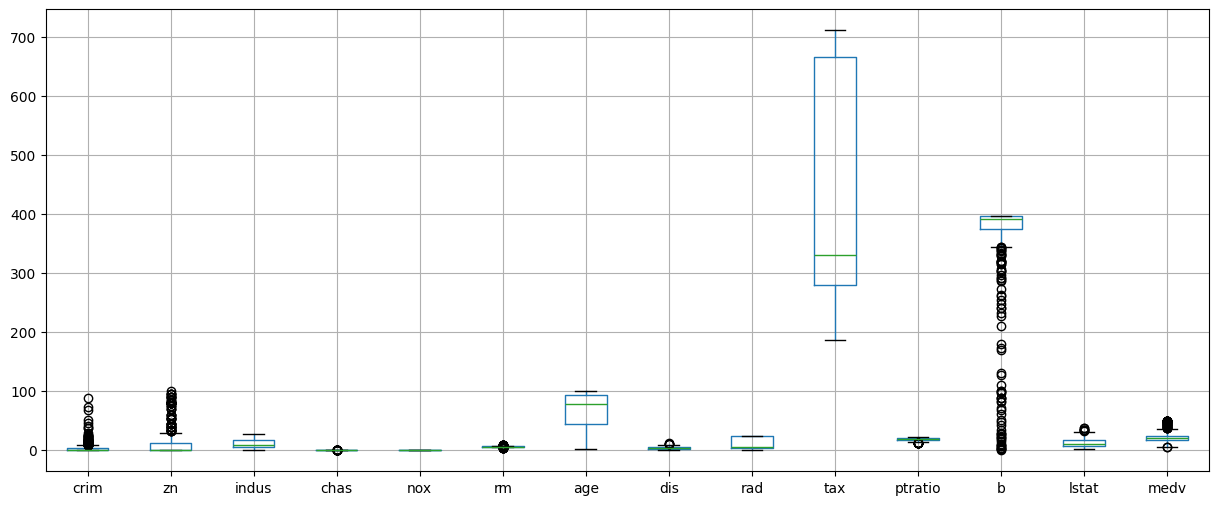

In [ ]:
df.boxplot(figsize=(15,6))
plt.show()

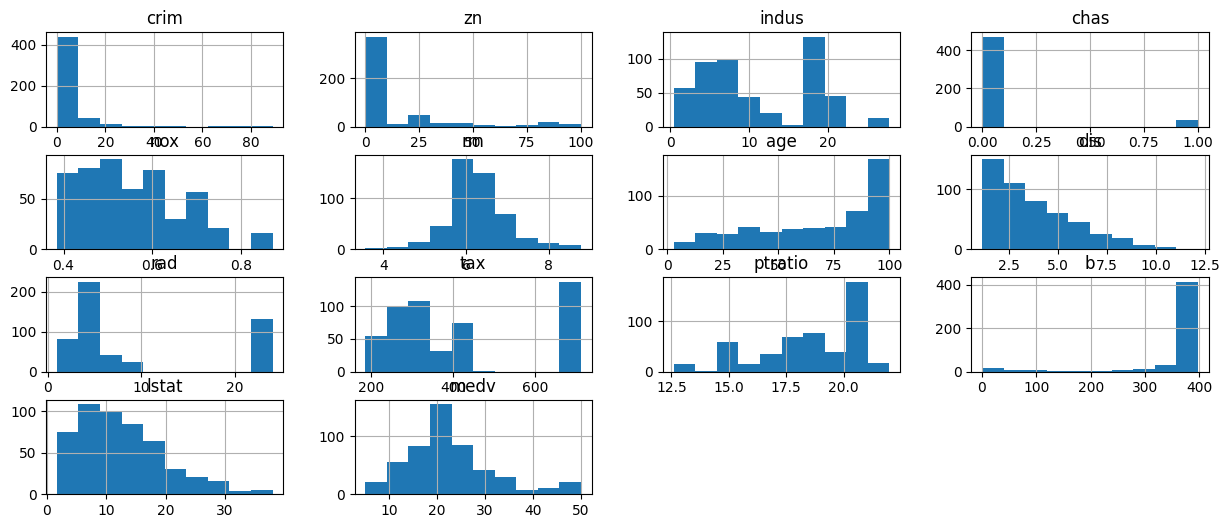

In [ ]:
df.hist(figsize=(15,6))
plt.show()

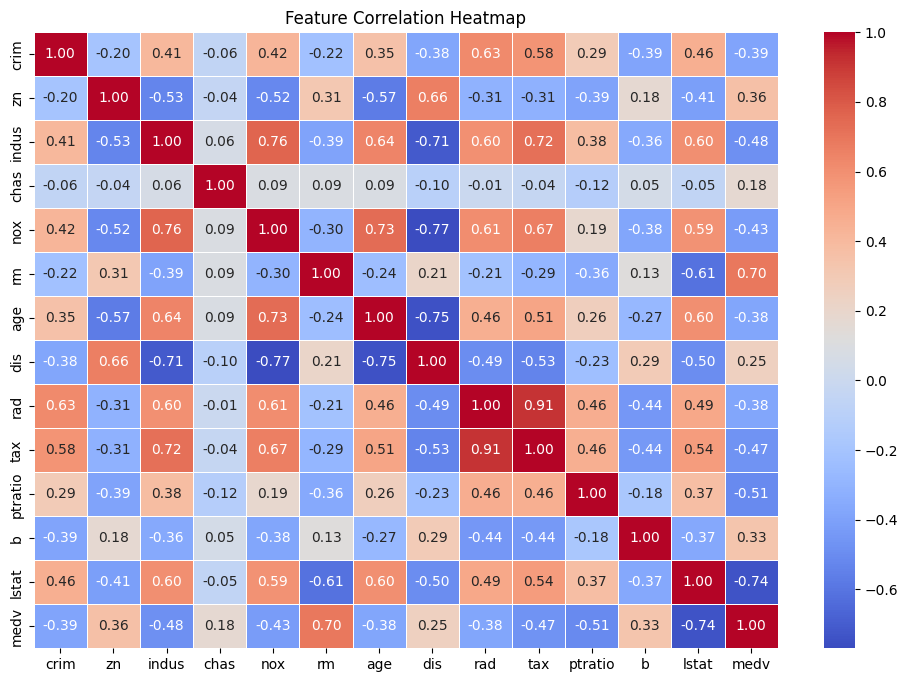

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

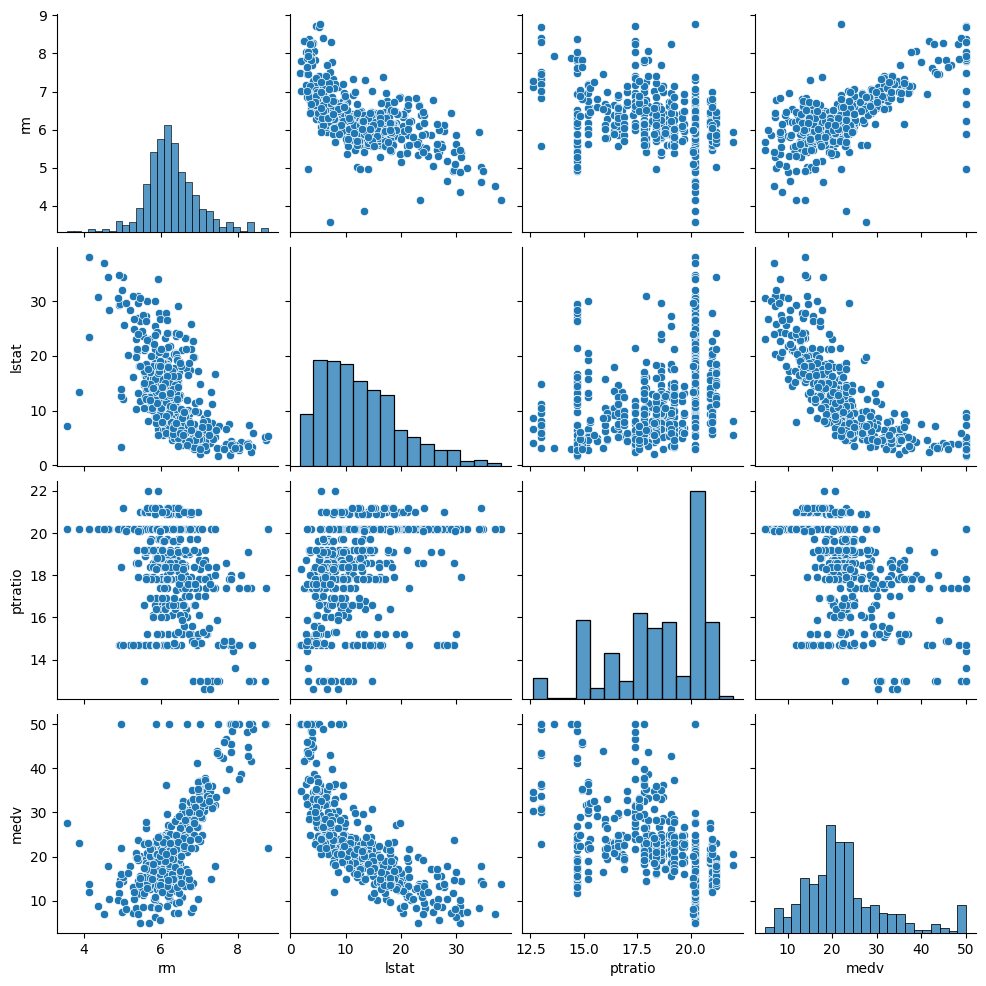

In [ ]:
sns.pairplot(df[['rm','lstat','ptratio','medv']])
plt.show()

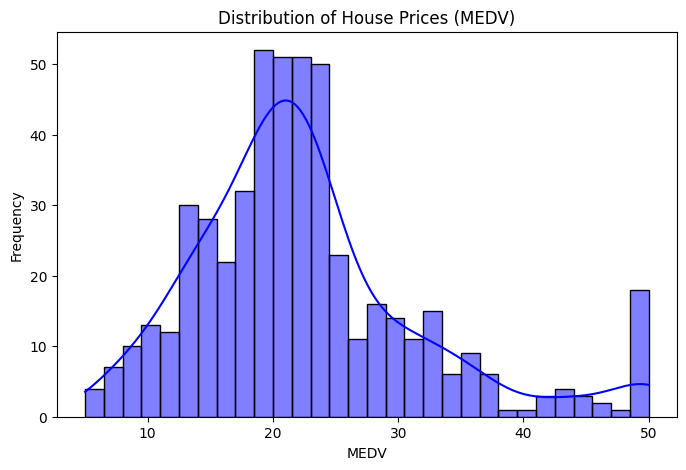

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['medv'],bins=30,kde=True,color='blue')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

**MODEL** **BUILDING**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=df.drop(columns=["medv"]) #All columns except target
y=df["medv"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Train linear regression model
model=LinearRegression()
model.fit(X_train,y_train)

#predictions
y_pred=model.predict(X_test)

#model evaluation
r2=r2_score(y_test,y_pred)
#rmse=mean_squared_error(y_test,y_pred,squared=False)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286


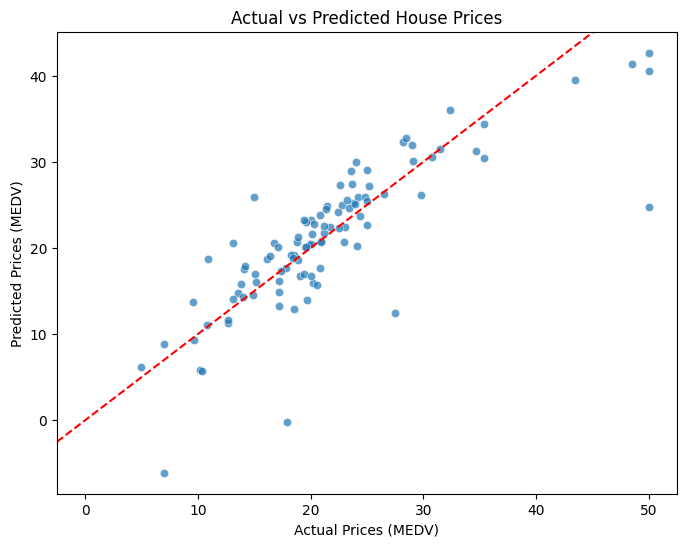

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Scatter plot of actual vs predicted values
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices (MEDV)")
plt.title("Actual vs Predicted House Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

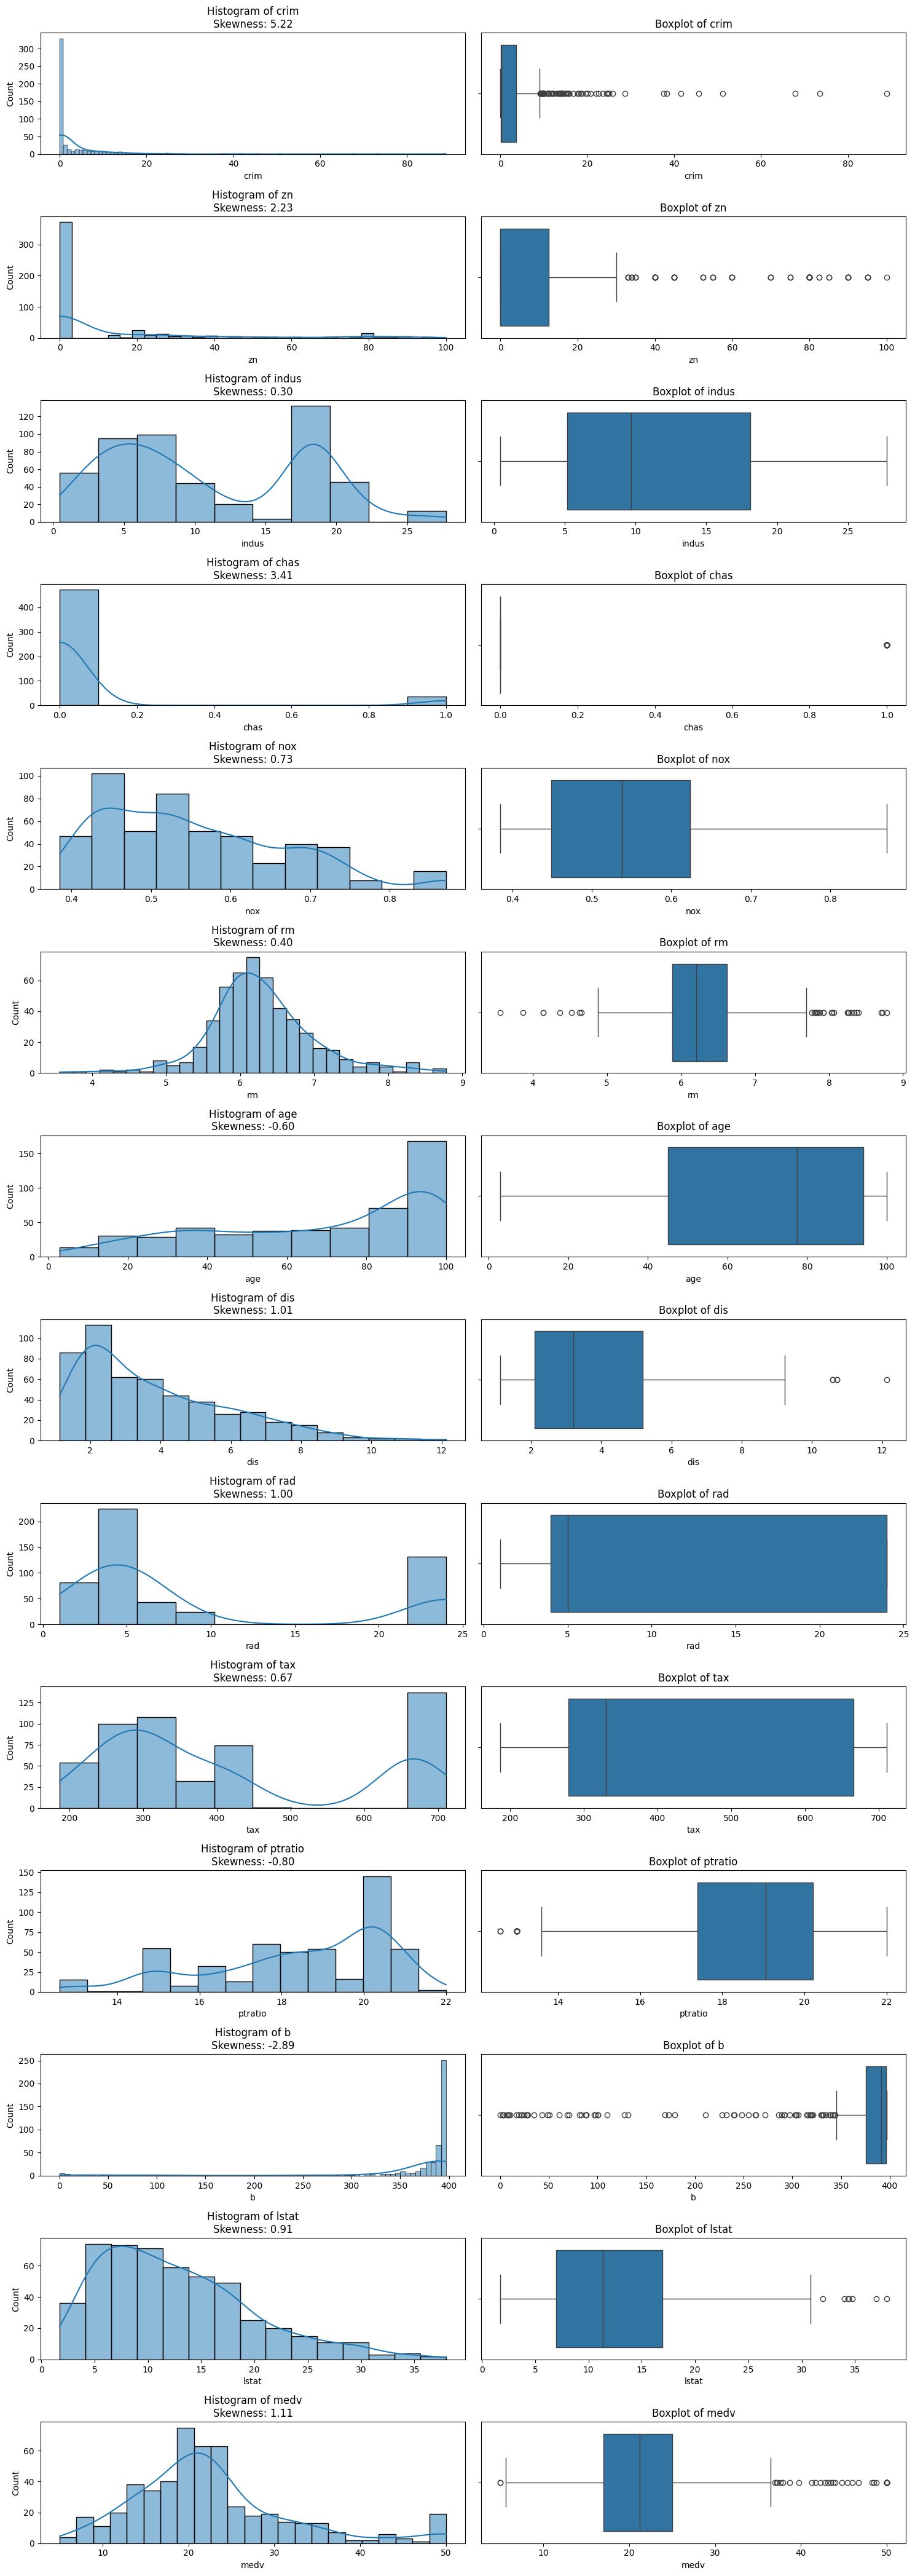

In [ ]:
from scipy.stats import skew

file_path="/content/boston.csv"

df=pd.read_csv(file_path)
skewness=df.skew()

num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}")

  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
skewed_cols=df.skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')
Negatively Skewed Columns:
 Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat'], dtype='object')


In [ ]:
df[highly_skewed]=df[highly_skewed].apply(lambda x: np.log1p(x))
df[highly_skewed]

,crim,zn,chas,dis,rad,b,medv
0,0.006300,2.944439,0.0,1.627278,0.693147,5.986201,3.218876
1,0.026944,0.000000,0.0,1.786261,1.098612,5.986201,3.117950
2,0.026924,0.000000,0.0,1.786261,1.098612,5.975919,3.575151
3,0.031857,0.000000,0.0,1.954757,1.386294,5.980479,3.538057
4,0.066770,0.000000,0.0,1.954757,1.386294,5.986201,3.616309
...,...,...,...,...,...,...,...
501,0.060747,0.000000,0.0,1.246630,0.693147,5.973784,3.152736
502,0.044275,0.000000,0.0,1.190127,0.693147,5.986201,3.072693
503,0.058986,0.000000,0.0,1.152943,0.693147,5.986201,3.214868
504,0.103991,0.000000,0.0,1.220505,0.693147,5.977492,3.135494


In [ ]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method="yeo-johnson")
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [ ]:
print(df.skew())

crim       1.269201
zn         1.193451
indus     -0.104641
chas       3.405904
nox        0.098431
rm         0.023275
age       -0.417736
dis        0.331561
rad        0.532760
tax        0.079613
ptratio   -0.220097
b         -4.459061
lstat     -0.017928
medv      -0.241244
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=df.drop(columns=["medv"]) #All columns except target
y=df["medv"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Train linear regression model
model=LinearRegression()
model.fit(X_train,y_train)

#predictions
y_pred=model.predict(X_test)

#model evaluation
r2=r2_score(y_test,y_pred)
#rmse=mean_squared_error(y_test,y_pred,squared=False)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7555
RMSE: 0.1842


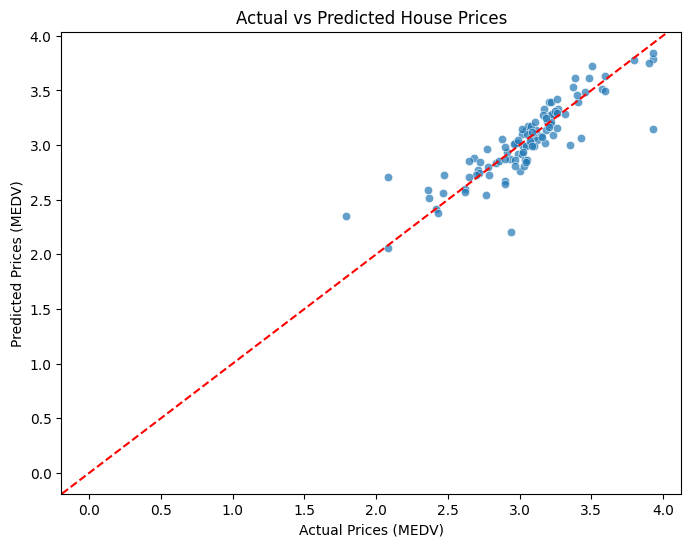

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices (MEDV)")
plt.title("Actual vs Predicted House Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define new features (X) and target (y) using the transformed dataset
X_transformed = df.drop(columns=["medv"])  # Keep transformed features
y_transformed = df["medv"]

# Split the transformed dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y_transformed, test_size=0.2, random_state=42)

# Train Linear Regression Model with transformed features
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Manually taking square root

print(f"📈 New R² Score: {r2:.4f}")
print(f"📉 New RMSE: {rmse:.4f}")

📈 New R² Score: 0.7555
📉 New RMSE: 0.1842


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X_transformed)

X_train,X_test,y_train,y_test=train_test_split(X_poly,y_transformed,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

r2=r2_score(y_test,y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Manually taking square root

print(f"Polynomial R² Score: {r2:.4f}")
print(f"Polynomial RMSE: {rmse:.4f}")


Polynomial R² Score: 0.8687
Polynomial RMSE: 0.1349


In [ ]:
# Define feature values manually
input_data = {
    "crim": float(input("Enter Crime Rate: ")),
    "zn": float(input("Enter Residential Land Zone: ")),
    "indus": float(input("Enter Non-Retail Business Acres: ")),
    "chas": int(input("Enter CHAS (0 or 1): ")),  # 1 if tract bounds river, else 0
    "nox": float(input("Enter NOX Concentration: ")),
    "rm": float(input("Enter Avg Rooms per Dwelling: ")),
    "age": float(input("Enter Age of Property: ")),
    "dis": float(input("Enter Distance to Employment Centers: ")),
    "rad": int(input("Enter Accessibility to Highways: ")),
    "tax": float(input("Enter Property Tax Rate: ")),
    "ptratio": float(input("Enter Pupil-Teacher Ratio: ")),
    "b": float(input("Enter Proportion of Black Residents: ")),
    "lstat": float(input("Enter Lower Status Population %: "))
}

# Convert to DataFrame
import pandas as pd
input_df = pd.DataFrame([input_data])

# Predict house price
predicted_price = model.predict(input_df)[0]

print(f" Predicted House Price (MEDV): {predicted_price:.2f}")

Enter Crime Rate: 0.0063
Enter Residential Land Zone: 12
Enter Non-Retail Business Acres: 3
Enter CHAS (0 or 1): 0
Enter NOX Concentration: .5
Enter Avg Rooms per Dwelling: 4
Enter Age of Property: 65.2
Enter Distance to Employment Centers: 4
Enter Accessibility to Highways: 3
Enter Property Tax Rate: 250
Enter Pupil-Teacher Ratio: 20
Enter Proportion of Black Residents: 300
Enter Lower Status Population %: 5
 Predicted House Price (MEDV): 5.04
